In [ ]:
import os
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [3]:
import os
import matplotlib.pyplot as plt


data_dir = "Garbage classification dataset"

classes = os.listdir(data_dir)
class_counts = {}

In [4]:
for cls in classes:
    class_path = os.path.join(data_dir, cls)
    class_counts[cls] = len(os.listdir(class_path))

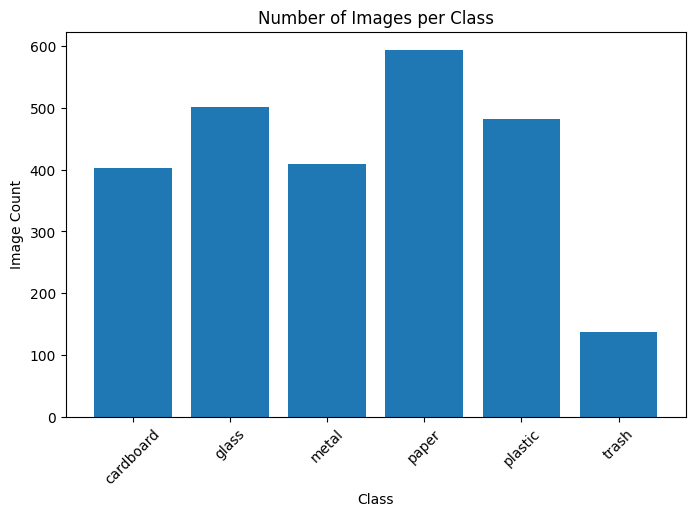

{'cardboard': 403,
 'glass': 501,
 'metal': 410,
 'paper': 594,
 'plastic': 482,
 'trash': 137}

In [5]:
import os
import matplotlib.pyplot as plt


classes = os.listdir(data_dir)

counts = {}
for cls in classes:
    folder = os.path.join(data_dir, cls)
    if os.path.isdir(folder):
        counts[cls] = len(os.listdir(folder))

# Plot class distribution
plt.figure(figsize=(8, 5))
plt.bar(counts.keys(), counts.values())
plt.title("Number of Images per Class")
plt.xlabel("Class")
plt.ylabel("Image Count")
plt.xticks(rotation=45)
plt.show()

counts


{'cardboard': 403,
 'glass': 501,
 'metal': 410,
 'paper': 594,
 'plastic': 482,
 'trash': 137}

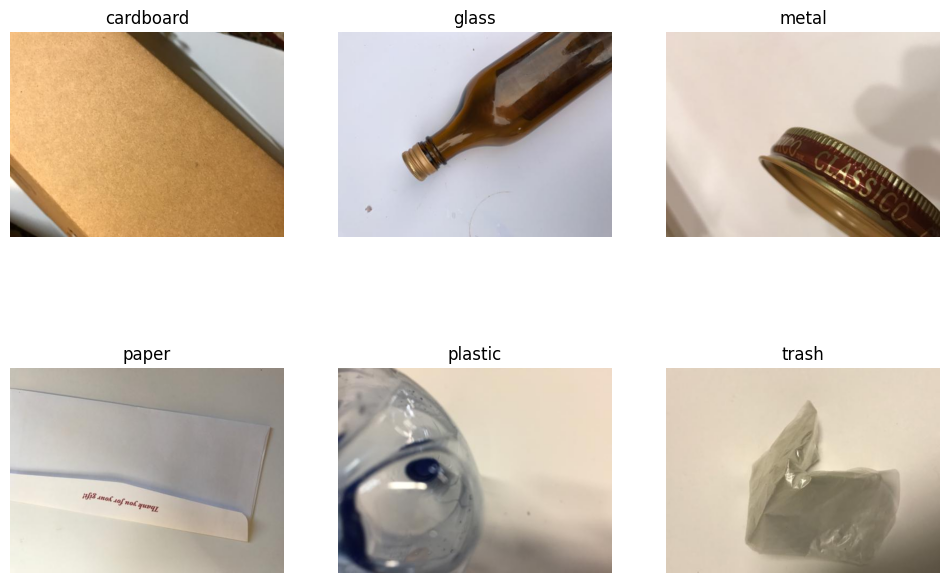

In [6]:
import cv2
import random

plt.figure(figsize=(12, 8))

i = 1
for cls in classes:
    folder = os.path.join(data_dir, cls)
    img_name = random.choice(os.listdir(folder))
    img_path = os.path.join(folder, img_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 3, i)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")
    i += 1

plt.show()


In [7]:
from PIL import Image
import os


classes = os.listdir(data_dir)

for cls in classes:
    folder = os.path.join(data_dir, cls)
    if os.path.isdir(folder):
        img_name = os.listdir(folder)[0]
        img_path = os.path.join(folder, img_name)
        img = Image.open(img_path)
        print(f"{cls} → {img.size}")


cardboard → (512, 384)
glass → (512, 384)
metal → (512, 384)
paper → (512, 384)
plastic → (512, 384)
trash → (512, 384)


In [8]:
from PIL import Image
import os

sizes = set()

for cls in os.listdir(data_dir):
    folder = os.path.join(data_dir, cls)
    if os.path.isdir(folder):
        for img_name in os.listdir(folder)[:20]:  # check first 20 images per class
            try:
                img = Image.open(os.path.join(folder, img_name))
                sizes.add(img.size)
            except:
                pass

print("Unique image sizes found:", sizes)


Unique image sizes found: {(512, 384)}


In [9]:
import os
print(os.listdir("Garbage classification dataset/plastic")[:10])


['plastic1.jpg', 'plastic10.jpg', 'plastic100.jpg', 'plastic101.jpg', 'plastic102.jpg', 'plastic103.jpg', 'plastic104.jpg', 'plastic105.jpg', 'plastic106.jpg', 'plastic107.jpg']


Pixel Intensity Analysis

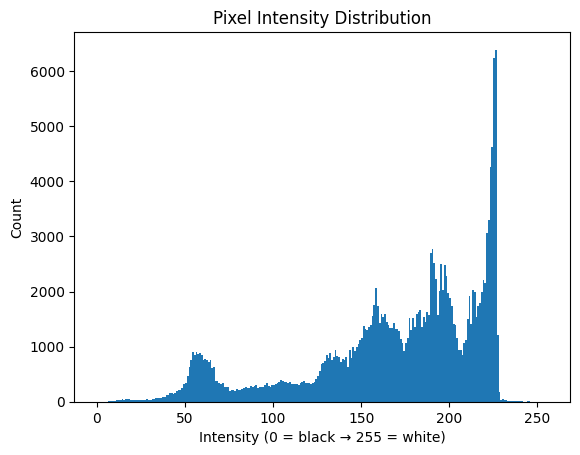

In [11]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("Garbage classification dataset//plastic/plastic236.jpg")   # use a valid filename
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.hist(gray.ravel(), bins=256, range=(0, 256))
plt.title("Pixel Intensity Distribution")
plt.xlabel("Intensity (0 = black → 255 = white)")
plt.ylabel("Count")
plt.show()


pixel internsity per class

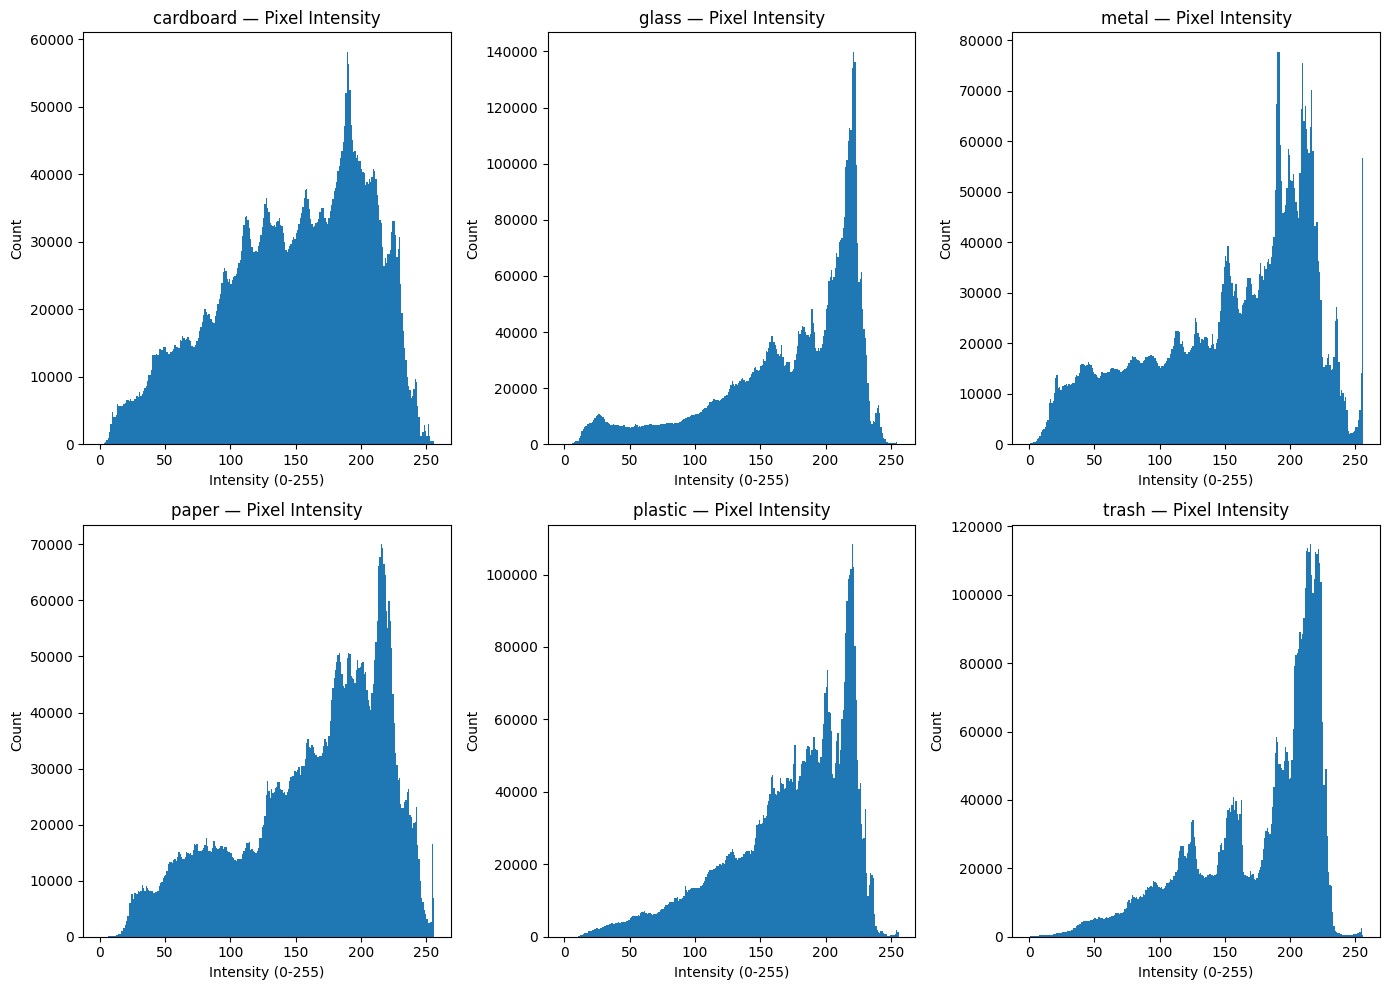

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image

classes = os.listdir(data_dir)

plt.figure(figsize=(14, 10))

for idx, cls in enumerate(classes):
    folder = os.path.join(data_dir, cls)
    if os.path.isdir(folder):
        intensities = []
        for img_name in os.listdir(folder)[:30]:
            try:
                img = cv2.imread(os.path.join(folder, img_name))
                gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                intensities.extend(gray.ravel())
            except:
                pass

        plt.subplot(2, 3, idx + 1)
        plt.hist(intensities, bins=256, range=(0, 256))
        plt.title(f"{cls} — Pixel Intensity")
        plt.xlabel("Intensity (0-255)")
        plt.ylabel("Count")

plt.tight_layout()
plt.show()


KeyboardInterrupt: 

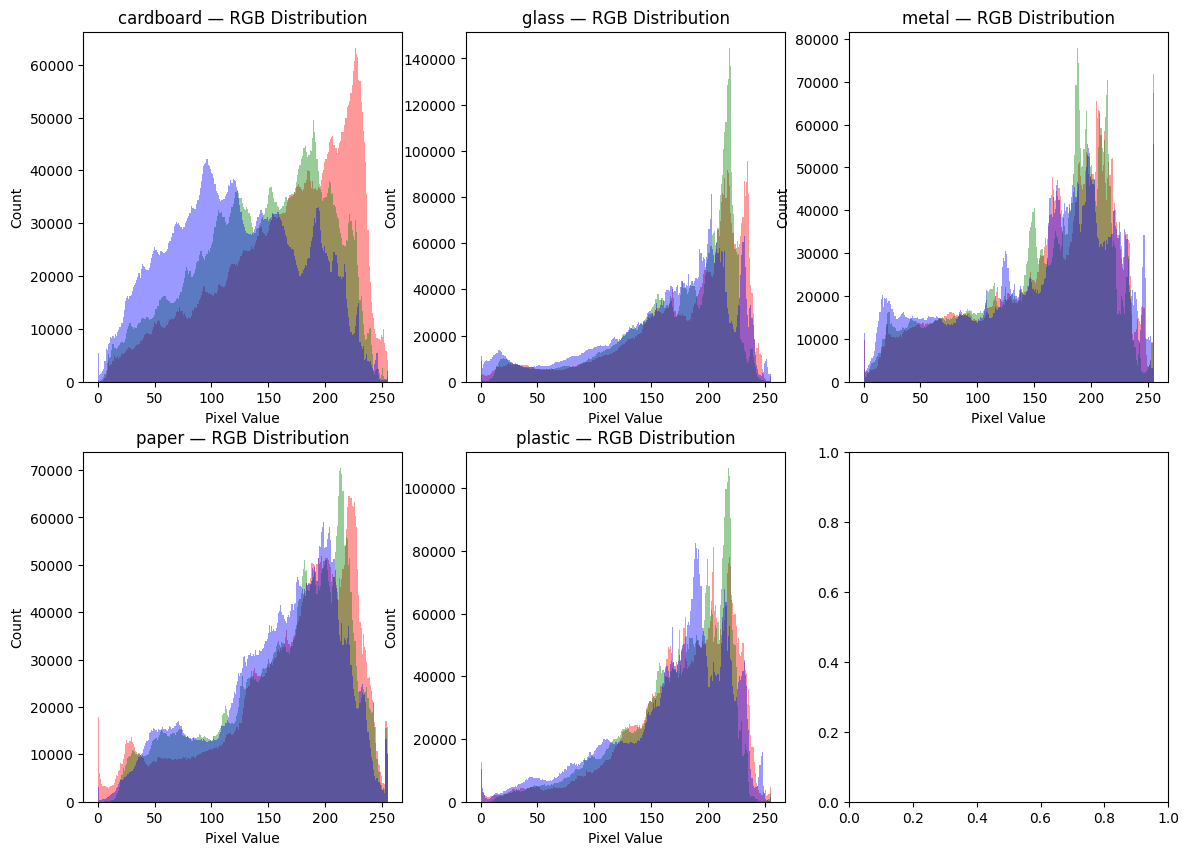

In [13]:
plt.figure(figsize=(14, 10))

for idx, cls in enumerate(classes):
    folder = os.path.join(data_dir, cls)
    if os.path.isdir(folder):
        reds, greens, blues = [], [], []
        for img_name in os.listdir(folder)[:30]:
            try:
                img = cv2.imread(os.path.join(folder, img_name))
                b, g, r = cv2.split(img)
                reds.extend(r.ravel())
                greens.extend(g.ravel())
                blues.extend(b.ravel())
            except:
                pass

        plt.subplot(2, 3, idx + 1)
        plt.hist(reds, bins=256, color='red', alpha=0.4)
        plt.hist(greens, bins=256, color='green', alpha=0.4)
        plt.hist(blues, bins=256, color='blue', alpha=0.4)
        plt.title(f"{cls} — RGB Distribution")
        plt.xlabel("Pixel Value")
        plt.ylabel("Count")

plt.tight_layout()
plt.show()


All classes have a lot of bright pixels (peaks near 180–240)

This means images are mostly bright / well-lit, not dark

Paper & Plastic look very similar

Their RGB histograms overlap heavily

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os

data_dir = "/content/drive/MyDrive/Garbage classification dataset"
class_name = "plastic"
img_name = os.listdir(os.path.join(data_dir, class_name))[0]
img_path = os.path.join(data_dir, class_name, img_name)

# Load original
original = cv2.imread(img_path)
original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

# Resize to generator input size
resized = cv2.resize(original, (224, 224))

# Generate 5 augmented versions
aug_iter = train_gen.flow(np.expand_dims(resized, 0), batch_size=1)
aug_images = [(next(aug_iter)[0] * 255).astype(np.uint8) for _ in range(5)]

# Display original + augmentations
plt.figure(figsize=(18, 6))

plt.subplot(2, 3, 1)
plt.imshow(resized)
plt.title("Original")
plt.axis("off")

for i in range(5):
    plt.subplot(2, 3, i + 2)
    plt.imshow(aug_images[i])
    plt.title(f"Augmented {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()
